# 01 Exploratory Data Analysis and Statistical Characterisation

This notebook provides the exploratory foundation for the MyAnimeList machine learning project. The objective is to understand the rating data before modelling by documenting the dataset structure, analysing descriptive statistics, creating interpretable derived variables, visualising distributions and relationships, and preparing scaled versions of selected numeric variables.

Exploratory data analysis is necessary because the quality of any supervised or unsupervised model depends on the assumptions made about the data. In this project, the central variable is `score`, a discrete rating from the MyAnimeList platform. The analysis therefore examines both the numeric behaviour of ratings and the behavioural context provided by watch status, rewatching, and episode consumption. All code cells are designed to make the statistical evidence visible before later notebooks apply predictive, classification, clustering, and recommendation methods.


## Dataset Description and Key EDA Decisions

- `ratings.csv` contains 2,423,185 user-anime interactions.
- Main features: `username`, `anime_id`, `status`, `score`, `is_rewatching`, and `num_watched_episodes`.
- Main supervised target: `score`, treated as a continuous rating from 1 to 10 after filtering invalid zero-score entries.
- After filtering `score > 0`, the dataset contains 1,351,334 valid ratings; after also removing impossible watched-episode values, it contains 1,351,284 modelling rows.

### Why Filter score = 0?

Scores of 0 represent unrated entries where users added anime to their list without assigning an evaluation. Including these records would bias regression models toward predicting 0 and would invalidate RMSE interpretation because 0 is not a genuine preference score in this context.

### Key EDA Findings

- The score distribution is concentrated around positive ratings, especially 7, 8, and 10.
- `completed` status is associated with higher scores, suggesting that completion behaviour contains useful preference signal.
- Numeric behavioural features have very low direct correlation with `score`, so limited predictive power is expected from ratings metadata alone.
- `num_watched_episodes` is zero-inflated and contains extreme outliers up to 65,535 episodes; impossible values are filtered and `log1p` is applied during preprocessing.


In [1]:
RANDOM_STATE = 42
SAMPLE_SIZE  = 50000
RATING_DTYPES = {
    'username': 'category',
    'anime_id': 'int32',
    'status': 'category',
    'score': 'float32',
    'is_rewatching': 'float32',
    'num_watched_episodes': 'float32',
}
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler

sys.path.append(os.path.abspath('..'))

%matplotlib inline
sns.set_theme(style='whitegrid')


## Dataset Description

The domain of this dataset is anime consumption and rating behaviour from MyAnimeList. The primary table, `ratings.csv`, represents user-anime interactions: each row corresponds to a user assigning or recording information for a specific anime. This means the dataset is not only an anime catalogue and not only a user table; it is an interaction table linking users, anime identifiers, watch status, episode progress, rewatch behaviour, and the numeric `score` target. The supplementary `details.csv` file contains anime-level metadata that can be used to contextualise titles, genres, formats, popularity, and other catalogue properties.

The printed shapes describe the size of each file in rows and columns. A large number of rows in `ratings.csv` indicates that the project can learn from repeated user-item interactions, which is valuable for both supervised learning and recommendation. The entity types are mainly users (`username`), anime items (`anime_id` or related identifiers), behavioural fields such as `status`, numeric progress variables such as `num_watched_episodes`, binary or boolean-like indicators such as rewatching, and the numeric rating `score`. These mixed data types require different treatment: numeric fields can be scaled and used directly after imputation, while categorical fields require encoding before most machine learning algorithms can use them.

The displayed `head`, `info`, and missing-value summaries are used to identify data types, sparsity, and potential data quality problems. Missing values can occur because users do not always rate every anime they list, because episode progress may be unavailable for dropped or planned titles, or because catalogue metadata can be incomplete for older, obscure, or newly added anime. Missingness is therefore not necessarily random: it may reflect user behaviour and platform recording practices. This is important because later modelling must use imputation carefully and avoid interpreting missing values as neutral observations without justification.


In [2]:
df = pd.read_csv('../datasets/ratings.csv', dtype=RATING_DTYPES)
df = df[df['score'] > 0]
details = pd.read_csv('../datasets/details.csv')

print(f'ratings.csv shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns')
print(f'details.csv shape: {details.shape[0]:,} rows x {details.shape[1]:,} columns')
display(df.head())
display(df.dtypes.to_frame('dtype'))
display(df.isna().sum().to_frame('missing_values'))


ratings.csv shape: 1,351,334 rows x 6 columns
details.csv shape: 28,955 rows x 29 columns


,username,anime_id,status,score,is_rewatching,num_watched_episodes
0,--------788,30276,watching,7.0,0.0,3.0
1,--------788,28851,completed,7.0,0.0,1.0
2,--------788,41168,completed,7.0,0.0,1.0
3,--------788,22199,completed,10.0,0.0,24.0
4,--------788,16498,completed,10.0,0.0,25.0


,dtype
username,category
anime_id,int32
status,category
score,float32
is_rewatching,float32
num_watched_episodes,float32


,missing_values
username,0
anime_id,0
status,0
score,0
is_rewatching,54229
num_watched_episodes,0


## Mean, Variance, Covariance, and Correlation Analysis

This section computes descriptive statistics for all numeric columns in the interaction dataset. The mean and median summarise the central tendency of each variable, while variance and standard deviation quantify dispersion. For the `score` variable, these statistics show whether user ratings are concentrated around a typical value or spread widely across the 0 to 10 scale. If the mean is higher than the midpoint of the scale, this suggests a positive-rating bias, which is common in voluntary rating platforms because users often watch anime they already expect to enjoy.

The variance values help identify variables with very different scales. Episode counts and item identifiers can have much larger numeric ranges than scores, which is why raw values should not be compared directly in distance-based models. High variance in episode progress may reflect structural differences between anime formats: movies, short series, long-running series, and specials have inherently different episode counts. This observation justifies later feature transformation and scaling.

The covariance matrix measures how numeric variables move together in their original units, while the correlation matrix standardises these relationships to values between -1 and 1. Strong positive correlations suggest that two variables carry similar information, whereas weak correlations indicate limited linear association. In this dataset, correlations involving `score` are especially relevant because they indicate which numeric behaviours may be predictive of rating. However, correlation does not imply causality: for example, users may complete more episodes because they like an anime, but completion may also depend on anime length, availability, or user habits.

The heatmap provides a visual summary of these relationships. Highly correlated predictors can increase redundancy for linear models, while tree-based methods are generally less sensitive to this issue. The correlation structure therefore informs both feature engineering and model selection in later notebooks.


,mean,median,var,std,min,max
anime_id,27764.246,31722.0,3.102428e+08,17613.710,1.0,62863.0
score,7.319,8.0,3.253000e+00,1.804,1.0,10.0
is_rewatching,0.001,0.0,1.000000e-03,0.037,0.0,1.0
num_watched_episodes,18.970,12.0,1.583785e+05,397.968,0.0,65535.0


,anime_id,score,is_rewatching,num_watched_episodes
anime_id,3.102428e+08,215.713,-6.838,-118077.376
score,2.157130e+02,3.253,0.002,-7.487
is_rewatching,-6.838000e+00,0.002,0.001,-0.001
num_watched_episodes,-1.180774e+05,-7.487,-0.001,158378.463


,anime_id,score,is_rewatching,num_watched_episodes
anime_id,1.000,0.007,-0.011,-0.017
score,0.007,1.000,0.024,-0.010
is_rewatching,-0.011,0.024,1.000,-0.000
num_watched_episodes,-0.017,-0.010,-0.000,1.000


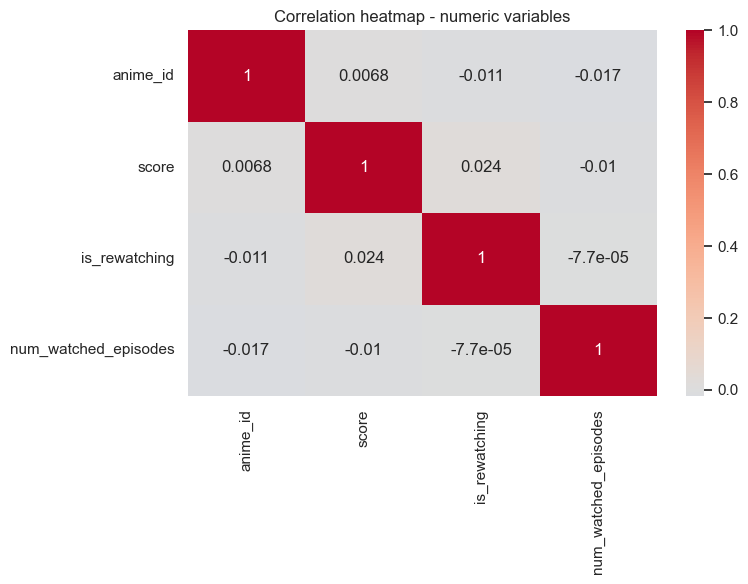

In [3]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()
stats = df[numeric_cols].agg(['mean', 'median', 'var', 'std', 'min', 'max']).T
display(stats.round(3))

display(df[numeric_cols].cov().round(3))
display(df[numeric_cols].corr().round(3))

plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation heatmap - numeric variables')
plt.tight_layout()
plt.show()


## Feature Engineering

This section creates additional variables that translate raw platform fields into more model-friendly behavioural signals. Feature engineering is important because the original dataset contains identifiers and activity logs, but many predictive patterns are better represented through derived features that encode user engagement and rating structure.

The feature `is_completed` converts the textual watch status into a binary indicator. Completion is expected to have predictive value because users who finish an anime may differ systematically from users who drop it or only plan to watch it. A completed anime may be associated with higher scores, although this relationship can also be biased because users are more likely to complete titles they enjoy.

The feature `watched_log1p` applies a logarithmic transformation to `num_watched_episodes`. Episode counts are usually right-skewed because most anime have modest length while a smaller number of long-running titles have very high episode counts. The log transformation reduces the influence of extreme values and makes the variable more suitable for linear models and distance-based algorithms.

The feature `score_bucket` groups continuous or discrete score values into qualitative rating bands. This supports descriptive analysis and can help interpret the distribution of low, medium, high, and excellent ratings. Finally, `has_rewatched` converts rewatching information into a binary behavioural indicator. Rewatching can be interpreted as a signal of strong engagement or preference, so it may be useful when predicting rating or classifying high-score interactions.


In [4]:
eda_df = df.copy()
eda_df['is_completed'] = (eda_df['status'] == 'completed').astype(int)
eda_df['watched_log1p'] = np.log1p(eda_df['num_watched_episodes'].fillna(0))
eda_df['score_bucket'] = pd.cut(
    eda_df['score'],
    bins=[-0.1, 4, 6, 8, 10],
    labels=['low', 'medium', 'good', 'excellent'],
)
eda_df['has_rewatched'] = (eda_df['is_rewatching'].fillna(0) > 0).astype(int)

display(eda_df[['score', 'status', 'is_completed', 'watched_log1p', 'score_bucket', 'has_rewatched']].head())
display(eda_df['score_bucket'].value_counts(dropna=False).to_frame('count'))


,score,status,is_completed,watched_log1p,score_bucket,has_rewatched
0,7.0,watching,0,1.386294,good,0
1,7.0,completed,1,0.693147,good,0
2,7.0,completed,1,0.693147,good,0
3,10.0,completed,1,3.218876,excellent,0
4,10.0,completed,1,3.258096,excellent,0


,count
score_bucket,
good,650414
excellent,343479
medium,263347
low,94094


## Visual Analysis: Distributions, Outliers, Categories, and Relationships

The visual analysis section uses histograms, boxplots, count plots, and scatter plots to inspect the empirical behaviour of the engineered dataset. The score histogram shows the distribution of ratings across the 0 to 10 scale. A concentration in the upper part of the scale would suggest positivity bias, while a multimodal distribution could indicate distinct user rating habits or differences between watched, dropped, and planned titles.

The boxplot of `score` by `status` compares rating distributions across watch-status categories. This plot is useful because the same numeric score can have different meaning depending on whether a user completed, dropped, or is currently watching an anime. Differences in medians or interquartile ranges indicate that status may contain predictive information. Outliers in the boxplot should not automatically be removed, because unusual ratings may represent genuine user opinions rather than data errors.

The count plot for `score_bucket` summarises how many interactions fall into each qualitative rating band. This is important for later classification because class imbalance can appear if high-score ratings are much more or much less frequent than lower ratings. The scatter plot comparing watched episodes and score is used to examine whether episode progress has a visible relationship with rating. Any observed relationship must be interpreted cautiously because episode counts are confounded by anime length and format.


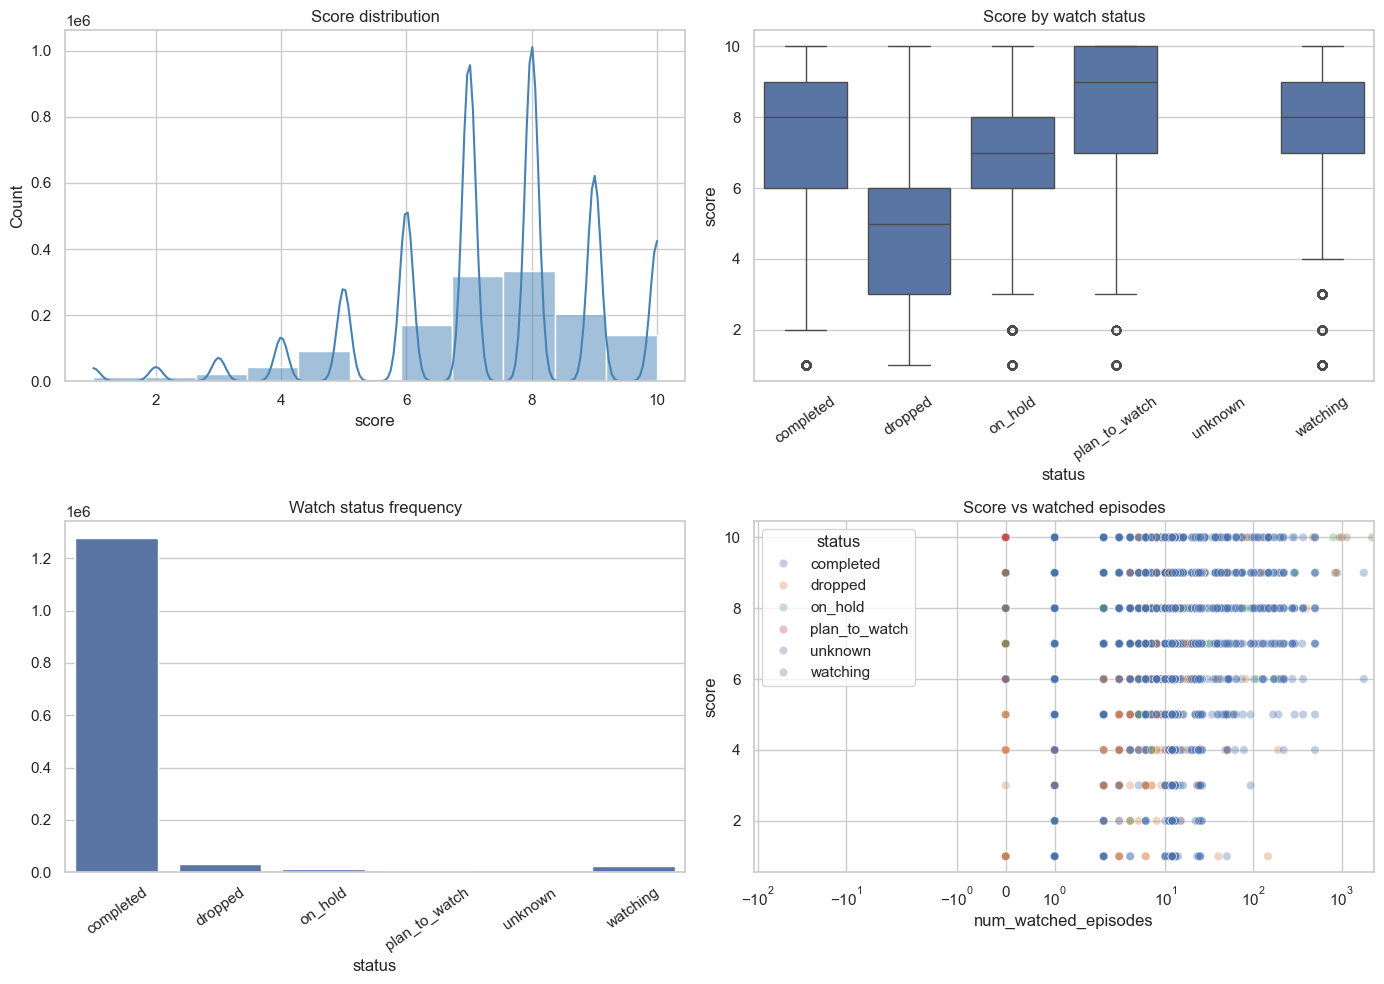

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(eda_df['score'], bins=11, kde=True, ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Score distribution')

sns.boxplot(data=eda_df, x='status', y='score', ax=axes[0, 1])
axes[0, 1].set_title('Score by watch status')
axes[0, 1].tick_params(axis='x', rotation=35)

status_counts = eda_df['status'].value_counts()
sns.barplot(x=status_counts.index, y=status_counts.values, ax=axes[1, 0])
axes[1, 0].set_title('Watch status frequency')
axes[1, 0].tick_params(axis='x', rotation=35)

sample_scatter = eda_df.sample(n=min(10000, len(eda_df)), random_state=42)
sns.scatterplot(
    data=sample_scatter,
    x='num_watched_episodes',
    y='score',
    hue='status',
    alpha=0.35,
    ax=axes[1, 1],
)
axes[1, 1].set_title('Score vs watched episodes')
axes[1, 1].set_xscale('symlog')

plt.tight_layout()
plt.show()


## Critical Interpretation

The dataset has strong modelling potential because it contains many user-anime interactions and a clear target variable, `score`. However, the target is discrete rather than truly continuous: although regression can estimate expected score, the model is learning values on a bounded rating scale from 0 to 10. This means RMSE should be interpreted relative to the scale, and predictions outside the natural rating range would need clipping or post-processing in a production application. The same target can also support classification by defining a high-score threshold, but this simplification loses information about differences between, for example, scores 1 and 6.

Data quality is shaped by the way users interact with MyAnimeList. Ratings are self-selected, meaning users who rate anime are not a random sample of all viewers. Users may rate only anime they strongly like or dislike, and many users maintain lists without consistently scoring every item. Missing values can therefore encode behaviour and should not be assumed to be random noise. In addition, identifiers such as `username` and `anime_id` have high cardinality. They are valuable for recommendation, but using them directly as one-hot features in standard supervised models can create sparse matrices, slow training, and increase the risk of memorising users or items rather than learning general patterns.

Bias is also present at the platform and cultural level. Popular anime may receive more ratings and more stable average behaviour, while niche titles may have fewer observations and higher variance. Long-running anime may appear differently from films or short specials because episode progress has a different meaning across formats. These biases affect feature interpretation: completion, rewatching, and watched-episode counts are behavioural signals, but they are not pure measures of quality. Later models must therefore be compared using validation metrics, fit-time analysis, and interpretability rather than assuming that every statistically visible pattern represents a causal effect.

For modelling, these observations imply that preprocessing is not optional. Numeric variables require imputation and scaling, categorical variables require encoding, and high-cardinality identifiers should be excluded from general supervised baselines or handled through recommendation-specific methods. The exploratory analysis therefore supports the design choices used in the subsequent notebooks.


## Normalisation and Standardisation

This section compares two common scaling approaches: standardisation and min-max normalisation. Standardisation transforms each numeric feature by subtracting its mean and dividing by its standard deviation, producing variables with approximately zero mean and unit variance. This is appropriate for models that are sensitive to feature scale, such as linear models with regularisation, support vector machines, K-NN, and neural networks. Standardisation is especially useful when variables have different units, such as ratings and episode counts.

Min-max normalisation rescales each feature to a fixed interval, usually from 0 to 1. This preserves the relative ordering of values and is useful when algorithms or visualisations benefit from bounded inputs. However, min-max scaling is more sensitive to extreme values because the minimum and maximum define the entire transformation. In this dataset, long-running anime can create extreme episode counts, so min-max scaling should be interpreted carefully unless outliers have been examined.

The displayed scaled tables allow direct comparison of how the same variables look under both transformations. Standardised values are easier to interpret in terms of deviations from the mean, while normalised values are easier to compare as proportions of the observed range. Later modelling primarily benefits from scale-consistent inputs, particularly for distance-based and gradient-based algorithms.


,score_standardized,num_watched_episodes_standardized,watched_log1p_standardized,is_completed_standardized,has_rewatched_standardized
count,1351334.000,1351334.000,1351334.000,1351334.000,1351334.000
mean,-0.000,-0.000,-0.000,0.000,-0.000
std,1.000,1.000,1.000,1.000,1.000
min,-3.503,-0.048,-2.176,-4.147,-0.036
25%,-0.731,-0.040,-0.839,0.241,-0.036
50%,0.378,-0.018,0.298,0.241,-0.036
75%,0.932,-0.015,0.369,0.241,-0.036
max,1.487,164.626,8.521,0.241,27.754


,score_normalized,num_watched_episodes_normalized,watched_log1p_normalized,is_completed_normalized,has_rewatched_normalized
count,1351334.000,1351334.000,1351334.000,1351334.000,1351334.000
mean,0.702,0.000,0.203,0.945,0.001
std,0.200,0.006,0.093,0.228,0.036
min,0.000,0.000,0.000,0.000,0.000
25%,0.556,0.000,0.125,1.000,0.000
50%,0.778,0.000,0.231,1.000,0.000
75%,0.889,0.000,0.238,1.000,0.000
max,1.000,1.000,1.000,1.000,1.000


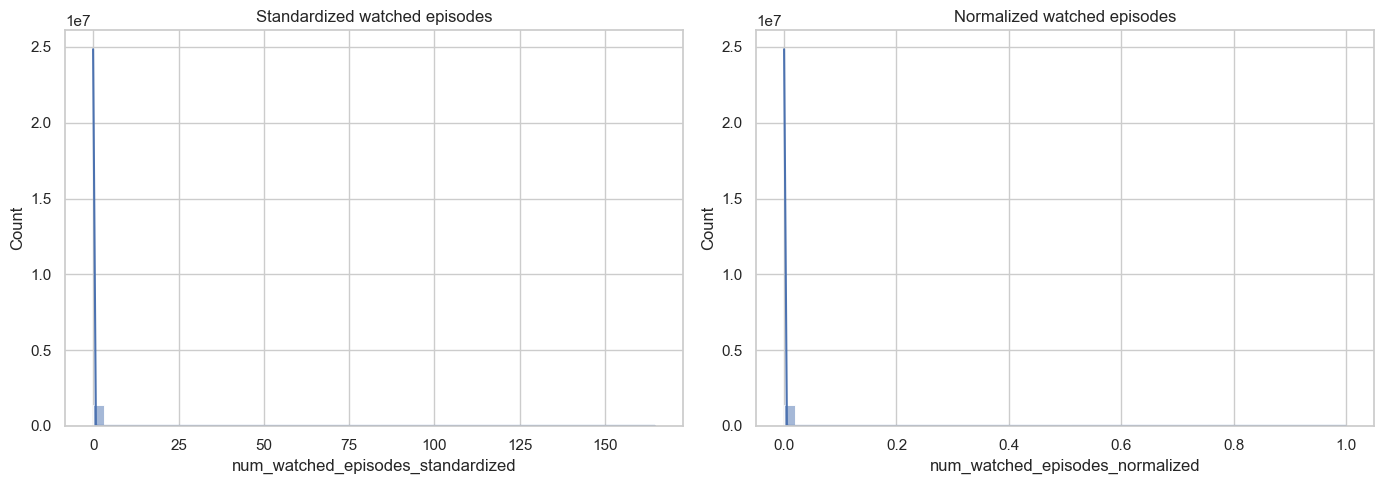

In [6]:
scale_cols = ['score', 'num_watched_episodes', 'watched_log1p', 'is_completed', 'has_rewatched']
scale_df = eda_df[scale_cols].fillna(eda_df[scale_cols].median())

standardized = pd.DataFrame(
    StandardScaler().fit_transform(scale_df),
    columns=[f'{col}_standardized' for col in scale_cols],
)
normalized = pd.DataFrame(
    MinMaxScaler().fit_transform(scale_df),
    columns=[f'{col}_normalized' for col in scale_cols],
)

display(standardized.describe().round(3))
display(normalized.describe().round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(standardized['num_watched_episodes_standardized'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Standardized watched episodes')
sns.histplot(normalized['num_watched_episodes_normalized'], bins=50, kde=True, ax=axes[1])
axes[1].set_title('Normalized watched episodes')
plt.tight_layout()
plt.show()
